# M2 - ElasticNet (Version Optimisée Linéaire)
Ce notebook combine la base robuste (TargetEncoder, Exclusion d'outliers) avec les optimisations spécifiques aux modèles linéaires (Log1p des asymétries, Variables d'interaction, Encodage Ordinal étendu).

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from sklearn.base import BaseEstimator, TransformerMixin
import warnings
warnings.filterwarnings('ignore')

### 1. Dictionnaires d'encodage ordinal

In [33]:
# Variables ordinales étendues (Inspiration Mélissa)
quality_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
exposure_map = {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4}
finish_map = {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}
garage_finish_map = {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3}
functional_map = {"Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4, "Mod": 5, "Min2": 6, "Min1": 7, "Typ": 8}
lot_shape_map = {"IR3": 1, "IR2": 2, "IR1": 3, "Reg": 4}
land_slope_map = {"Sev": 1, "Mod": 2, "Gtl": 3}
paved_drive_map = {"N": 0, "P": 1, "Y": 2}
central_air_map = {"N": 0, "Y": 1}

ordinal_mappings = {
    "ExterQual": quality_map, "ExterCond": quality_map,
    "BsmtQual": quality_map, "BsmtCond": quality_map,
    "HeatingQC": quality_map, "KitchenQual": quality_map,
    "FireplaceQu": quality_map, "GarageQual": quality_map,
    "GarageCond": quality_map, "PoolQC": quality_map,
    "BsmtExposure": exposure_map,
    "BsmtFinType1": finish_map, "BsmtFinType2": finish_map,
    "GarageFinish": garage_finish_map,
    "Functional": functional_map,
    "LotShape": lot_shape_map,
    "LandSlope": land_slope_map,
    "PavedDrive": paved_drive_map,
    "CentralAir": central_air_map,
}

# Colonnes dont les NaN signifient "absence" (pas de garage, pas de sous-sol, etc.)
none_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType"
]

### 2. Feature Engineering

In [34]:
def advanced_feature_engineering(data):
    df = data.copy()

    # 0. Faux-manquants catégoriels -> "None" AVANT l'encodage ordinal
    for col in none_cols:
        if col in df.columns:
            df[col] = df[col].fillna("None")

    # 1. Gestion des Zéros pour les variables de surface/quantité manquantes
    numeric_zero_cols = [
        "TotalBsmtSF", "1stFlrSF", "2ndFlrSF",
        "FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath",
        "GarageCars", "GarageArea", "Fireplaces", "PoolArea",
        "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch",
        "WoodDeckSF", "MasVnrArea"
    ]
    for col in numeric_zero_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # 2. Création de variables de base (Alain M3)
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBath'] = df['FullBath'] + 0.5 * df['HalfBath'] + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath']
    df['IsRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)
    
    # 3. Ages
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    
    # 4. Variables booléennes de présence
    df["HasPool"] = (df["PoolArea"] > 0).astype(int)
    df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
    df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
    df["HasBasement"] = (df["TotalBsmtSF"] > 0).astype(int)

    # 5. Surface totale des porches/terrasses
    df["TotalPorchSF"] = (
        df["OpenPorchSF"] + df["EnclosedPorch"] +
        df["3SsnPorch"] + df["ScreenPorch"] + df["WoodDeckSF"]
    )

    # 6. Interactions Linéaires (Inspiration Mélissa)
    if "OverallQual" in df.columns and "OverallCond" in df.columns:
        df["OverallScore"] = df["OverallQual"] * df["OverallCond"]

    if "OverallQual" in df.columns:
        df["OverallQual_GrLivArea"] = df["OverallQual"] * df["GrLivArea"]
        df["OverallQual_TotalSF"] = df["OverallQual"] * df["TotalSF"]
        df["OverallQual_TotalBath"] = df["OverallQual"] * df["TotalBath"]
        df["GarageCars_OverallQual"] = df["GarageCars"] * df["OverallQual"]
        df["OverallQual_HouseAge"] = df["OverallQual"] * df["HouseAge"]

    # 7. Encodage Ordinal (après avoir rempli les "None")
    for col, mapping in ordinal_mappings.items():
        if col in df.columns:
            df[col] = df[col].map(mapping).fillna(0).astype(float)
            
    # 8. MSSubClass est une catégorie, pas un chiffre mathématique
    if 'MSSubClass' in df.columns:
        df['MSSubClass'] = df['MSSubClass'].astype(str)
        
    # 9. Nettoyage des colonnes brutes d'année
    df = df.drop(['YearBuilt', 'YearRemodAdd', 'GarageYrBlt'], axis=1, errors='ignore')
    return df

# Chargement
train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

# Outliers (Uniquement les anomalies : grande surface ET prix bas)
train_df = train_df.drop(train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)].index)

# Imputation de LotFrontage par médiane du quartier (avant FE, car on a besoin de Neighborhood)
lotfrontage_by_neigh = train_df.groupby('Neighborhood')['LotFrontage'].median().to_dict()
lotfrontage_global = train_df['LotFrontage'].median()

for df_tmp in [train_df, test_df]:
    df_tmp['LotFrontage'] = df_tmp['LotFrontage'].fillna(df_tmp['Neighborhood'].map(lotfrontage_by_neigh))
    df_tmp['LotFrontage'] = df_tmp['LotFrontage'].fillna(lotfrontage_global)

# Feature Engineering
train_df = advanced_feature_engineering(train_df)
test_df = advanced_feature_engineering(test_df)

X_train = train_df.drop(['Id', 'SalePrice'], axis=1)
y_train = pd.Series(np.log1p(train_df['SalePrice']), index=train_df.index)

X_test = test_df.drop(['Id'], axis=1)
test_ids = test_df['Id']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Colonnes numériques: {len(X_train.select_dtypes(include=[np.number]).columns)}")
print(f"Colonnes catégorielles: {len(X_train.select_dtypes(include=['object']).columns)}")

X_train shape: (1458, 92)
X_test shape:  (1459, 92)
Colonnes numériques: 67
Colonnes catégorielles: 25


### 3. Gestion de l'asymétrie et Preprocessing

In [35]:
class SkewnessTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.75):
        self.threshold = threshold
        self.skewed_cols = []
        
    def fit(self, X, y=None):
        skewness = X.skew(numeric_only=True)
        self.skewed_cols = [
            col for col in X.columns 
            if abs(skewness.get(col, 0)) > self.threshold and X[col].min(skipna=True) >= 0
        ]
        return self
        
    def transform(self, X):
        X = X.copy()
        for col in self.skewed_cols:
            if col in X.columns:
                X[col] = np.log1p(X[col].clip(lower=0))
        return X

# Répartition des colonnes
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

# Les variables ordinales ont déjà été encodées en float, elles sont dans numeric_features.
# Les cat_none ont aussi été encodées. Il ne reste que les vraies catégorielles (Neighborhood, etc.)
cat_freq_features = list(categorical_features)

# Pipeline Numérique (Lissage Skewness -> KNN pour les rares NaN restants -> Robust -> StandardScaler)
numeric_transformer = Pipeline(steps=[
    ('skewness', SkewnessTransformer(threshold=0.75)),
    ('imputer', KNNImputer(n_neighbors=5)),
    ('robust', RobustScaler()),
    ('scaler', StandardScaler())
])

# Pipeline Catégorielle (TargetEncoder uniquement, pas de OneHotEncoder)
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder(smoothing=10, handle_unknown='value', handle_missing='value'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', cat_transformer, cat_freq_features)
    ])

print(f"Features numériques dans le pipeline: {len(numeric_features)}")
print(f"Features catégorielles dans le pipeline: {len(cat_freq_features)}")
print(f"Catégorielles: {list(cat_freq_features)}")

Features numériques dans le pipeline: 67
Features catégorielles dans le pipeline: 25
Catégorielles: ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'GarageType', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


### 4. Fonctions d'évaluation

In [36]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def calculate_business_metrics(y_true, y_pred):
    y_true_real = np.expm1(y_true)
    y_pred_real = np.expm1(y_pred)
    metrics = {
        'RMSE (Log)': np.sqrt(mean_squared_error(y_true, y_pred)),
        'RMSE ($)': np.sqrt(mean_squared_error(y_true_real, y_pred_real)),
        'MAE ($)': mean_absolute_error(y_true_real, y_pred_real),
        'R2': r2_score(y_true_real, y_pred_real),
        'Erreur Médiane ($)': np.median(np.abs(y_true_real - y_pred_real))
    }
    return metrics

def display_metrics(metrics_dict):
    print("=== Évaluation du Modèle ===")
    print(f"Kaggle RMSE (Log) : {metrics_dict['RMSE (Log)']:.5f}")
    print(f"R² Score         : {metrics_dict['R2']:.4f}")
    print("\nMétriques Métier ($) :")
    print(f"Erreur Moyenne (MAE)   : ${metrics_dict['MAE ($)']:,.0f}")
    print(f"Erreur Médiane         : ${metrics_dict['Erreur Médiane ($)']:,.0f}")
    print(f"Erreur Quad. (RMSE $)  : ${metrics_dict['RMSE ($)']:,.0f}")

### 5. Tuning ElasticNetCV et Soumission

Calcul des prédictions OOF...
=== Évaluation du Modèle ===
Kaggle RMSE (Log) : 0.11553
R² Score         : 0.9259

Métriques Métier ($) :
Erreur Moyenne (MAE)   : $14,366
Erreur Médiane         : $10,136
Erreur Quad. (RMSE $)  : $21,632

--- Hyperparamètres Finaux ---
Meilleur l1_ratio : 1.0
Meilleur alpha    : 0.00047


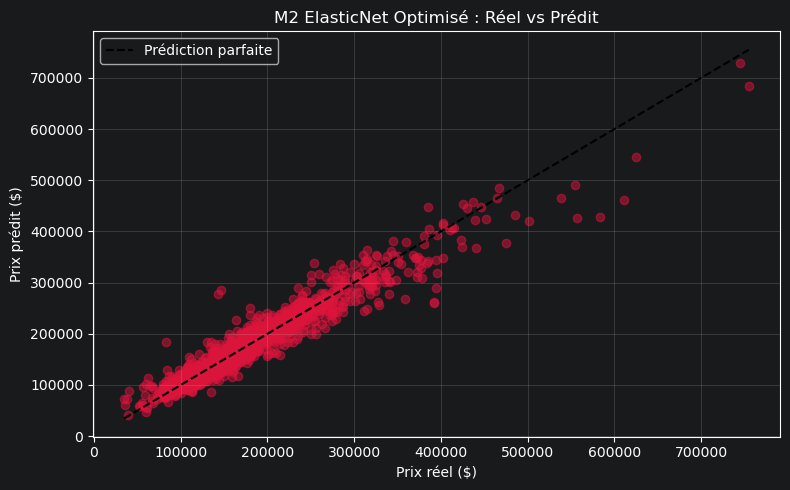


Fichier de soumission créé : submission_ElasticNet_Alain_M2.csv
     Id      SalePrice
0  1461  115869.865605
1  1462  154930.638050
2  1463  179683.485704
3  1464  198369.843568
4  1465  195282.612164


In [37]:
elastic_net_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.2, 0.4, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
    cv=5,
    random_state=42,
    max_iter=100000,
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', elastic_net_cv)
])

print("Calcul des prédictions OOF...")
oof_preds = np.zeros(len(X_train))
for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    
    pipeline.fit(X_tr, y_tr)
    oof_preds[val_idx] = pipeline.predict(X_val)

metrics = calculate_business_metrics(y_train, oof_preds)
display_metrics(metrics)

# Entraînement final sur tout le train
pipeline.fit(X_train, y_train)
best_model = pipeline.named_steps['model']
print("\n--- Hyperparamètres Finaux ---")
print(f"Meilleur l1_ratio : {best_model.l1_ratio_}")
print(f"Meilleur alpha    : {best_model.alpha_:.5f}")

# Graphe Réel vs Prédit
plt.figure(figsize=(8, 5))
plt.scatter(np.expm1(y_train), np.expm1(oof_preds), alpha=0.5, color='crimson')
y_min, y_max = np.expm1(y_train).min(), np.expm1(y_train).max()
plt.plot([y_min, y_max], [y_min, y_max], 'k--', label='Prédiction parfaite')
plt.xlabel('Prix réel ($)')
plt.ylabel('Prix prédit ($)')
plt.title('M2 ElasticNet Optimisé : Réel vs Prédit')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Soumission
test_preds = np.expm1(pipeline.predict(X_test))
test_preds = np.maximum(test_preds, 0)  # Sécurité : prix >= 0
submission = pd.DataFrame({'Id': test_ids, 'SalePrice': test_preds})
submission.to_csv('submission_ElasticNet_Alain_M2.csv', index=False)
print(f"\nFichier de soumission créé : submission_ElasticNet_Alain_M2.csv")
print(submission.head())